In [8]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool")
db_path = project_root / "data" / "thesis_database.db"

conn = sqlite3.connect(db_path)

In [10]:
query = """
SELECT name 
FROM sqlite_master 
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)
tables

,name
0,Regions
1,sqlite_sequence
2,BiddingZones
3,Prices
4,Volumes
5,Flows
6,Capacities


In [11]:
query = """
SELECT *
FROM Prices
"""

df_prices = pd.read_sql_query(query, conn)

df_prices.head()

,price_id,zone_id,delivery_day,hour,price_value
0,1,1,2020-01-01,0,28.78
1,2,2,2020-01-01,0,28.78
2,3,3,2020-01-01,0,28.78
3,4,4,2020-01-01,0,41.88
4,5,5,2020-01-01,0,41.88


In [12]:
df_prices.columns

Index(['price_id', 'zone_id', 'delivery_day', 'hour', 'price_value'], dtype='object')

In [13]:
df_prices.shape
df_prices.head()

,price_id,zone_id,delivery_day,hour,price_value
0,1,1,2020-01-01,0,28.78
1,2,2,2020-01-01,0,28.78
2,3,3,2020-01-01,0,28.78
3,4,4,2020-01-01,0,41.88
4,5,5,2020-01-01,0,41.88


## **Create temporal series**

In [22]:
# Filter a single zone
df = df_prices[df_prices["zone_id"] == 12].copy()

In [23]:
# Create datetime column from date and hour
df["datetime"] = (
    pd.to_datetime(df["delivery_day"]) 
    + pd.to_timedelta(df["hour"], unit="h")
)

In [24]:
# Sort by datetime
df = df.sort_values("datetime")

In [25]:
# Localize to Oslo timezone and convert to UTC
df["datetime"] = (
    df["datetime"]
    .dt.tz_localize("Europe/Oslo", ambiguous="infer", nonexistent="shift_forward")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)

In [26]:
# Sort again after timezone conversion
df = df.sort_values("datetime")

In [27]:
# Check for duplicate timestamps
df["datetime"].duplicated().sum()

0

In [28]:
# Set datetime as index
df = df.set_index("datetime")

In [29]:
# Extract price series
ts = df["price_value"]

In [31]:
# Set hourly frequency
ts = ts.asfreq("h")

In [32]:
# Check missing values
ts.isna().sum()

0

In [33]:
# Final checks
print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing:", ts.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

Length: (50399,)
Duplicates: 0
Missing: 0
Start: 2019-12-31 23:00:00
End: 2025-09-30 21:00:00


**Check if the serie is stationary**

In [34]:
# Perform ADF test
result = adfuller(ts)

# Extract results
adf_stat = result[0]
p_value = result[1]

print("ADF Statistic:", adf_stat)
print("p-value:", p_value)

ADF Statistic: -5.930578230047201
p-value: 2.3859867770941873e-07


In [37]:
from pmdarima import auto_arima

# Automatic ARIMA parameter selection
ts_2020 = ts["2020-01-01":"2020-12-31"]

model_auto = auto_arima(
    ts_2020,
    d=0,
    seasonal=False,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    trace=True,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=69216.114, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.46 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=58762.497, Time=0.33 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=35146.402, Time=0.52 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=35116.498, Time=1.25 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.55 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=35075.469, Time=1.22 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=35121.989, Time=0.79 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=34787.305, Time=3.59 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=35038.915, Time=2.68 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=34201.921, Time=3.89 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=34234.769, Time=3.31 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=34209.202, Time=8.08 sec

Best model:  ARIMA(3,0,3)(0,0,0)[0]          
Total fit time: 26.743 seconds
                    

**Train real model**

In [52]:
# Use only 2020
ts_model = ts["2020-01-01":"2020-12-31"]

# Train/test split for one-week short-term evaluation
train = ts_model["2020-01-01":"2020-11-30 23:00:00"]
test = ts_model["2020-12-01":"2020-12-07 23:00:00"]

In [53]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA model
model = ARIMA(train, order=(3, 0, 3))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:            price_value   No. Observations:                 8040
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -11737.622
Date:                Thu, 30 Apr 2026   AIC                          23491.243
Time:                        19:23:45   BIC                          23547.181
Sample:                    01-01-2020   HQIC                         23510.385
                         - 11-30-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.9081      7.182      2.493      0.013       3.832      31.985
ar.L1          2.0241      0.008    257.853      0.000       2.009       2.040
ar.L2         -1.3289      0.017    -80.350      0.0

In [54]:
history = list(train)
predictions = []

# Rolling one-step ahead forecast
for t in range(len(test)):
    model = ARIMA(history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Add real observation to history
    history.append(test.iloc[t])

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate model
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.878555890315396
RMSE: 1.1662748575410418


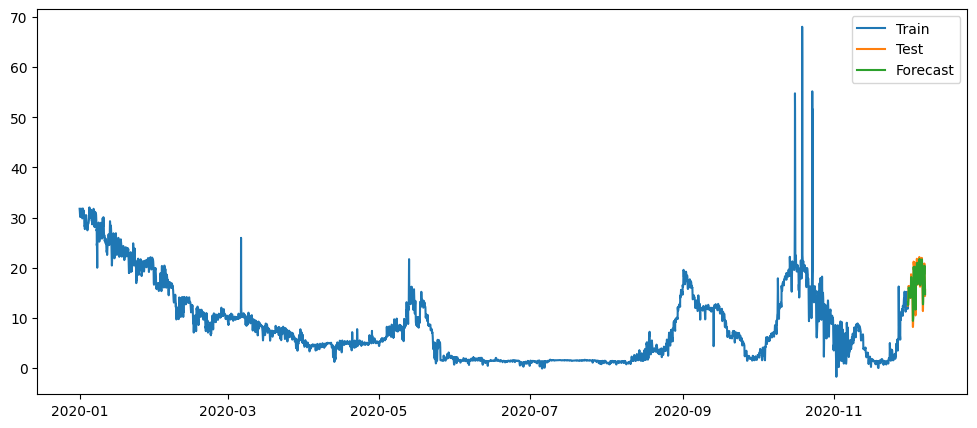

In [56]:
import matplotlib.pyplot as plt

# Plot results
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, predictions, label="Forecast")

plt.legend()
plt.show()

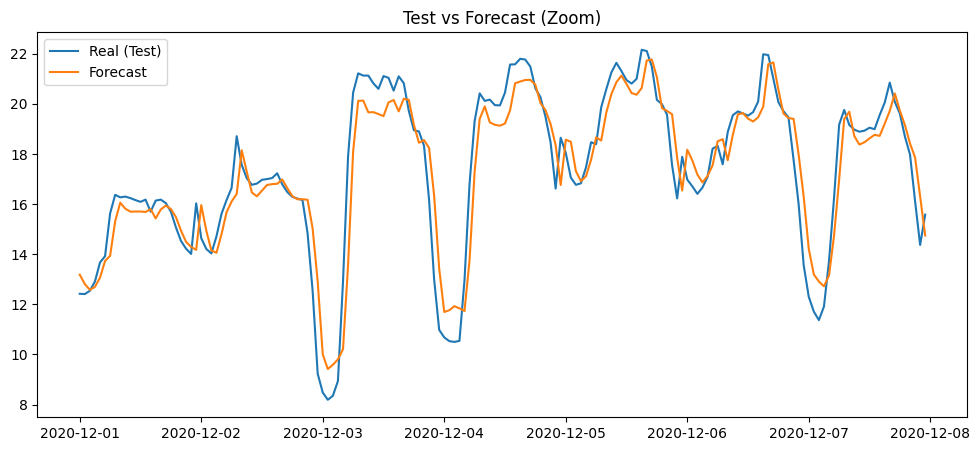

In [57]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Real (Test)")
plt.plot(test.index, predictions, label="Forecast")

plt.legend()
plt.title("Test vs Forecast (Zoom)")
plt.show()

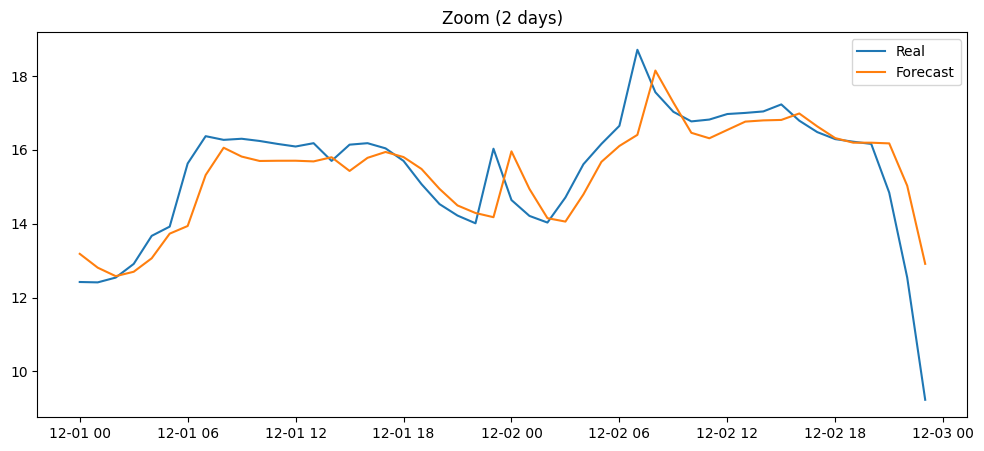

In [58]:
# Select a smaller window
zoom_test = test["2020-12-01":"2020-12-02"]
zoom_pred = predictions[:len(zoom_test)]

plt.figure(figsize=(12,5))

plt.plot(zoom_test.index, zoom_test, label="Real")
plt.plot(zoom_test.index, zoom_pred, label="Forecast")

plt.legend()
plt.title("Zoom (2 days)")
plt.show()